In [13]:
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.utils.class_weight import compute_class_weight
import json
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    roc_curve,
    precision_recall_curve
)


from pathlib import Path
import sys


PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

In [2]:
def load_train_test(train_path, test_path, target_col='is_fraud'):
    # Loading and Splitting the data into X (features) and y (target)
    train_df = pd.read_csv(train_path)
    test_df  = pd.read_csv(test_path)

    X_train = train_df.drop(columns=[target_col])
    y_train = train_df[target_col]

    X_test  = test_df.drop(columns=[target_col])
    y_test  = test_df[target_col]

    return X_train, y_train, X_test, y_test


In [3]:
def preprocess_data(X_train, X_test, categorical_cols):
  # One hot encoding for categorical cols and standard scaling for numeric features
    numerical_cols = [c for c in X_train.columns if c not in categorical_cols]

    preprocessor = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), numerical_cols),
            ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False),categorical_cols)
        ]
    )

    X_train_processed = preprocessor.fit_transform(X_train)
    X_test_processed = preprocessor.transform(X_test)

    return X_train_processed, X_test_processed, preprocessor


In [4]:
# Building encoder models and autoencoder
def build_autoencoder(input_dim):
    encoding_dim1 = input_dim // 2
    encoding_dim2 = input_dim // 4

    input_layer = Input(shape=(input_dim,))
    encoded = Dense(encoding_dim1, activation='relu')(input_layer)
    encoded = Dense(encoding_dim2, activation='relu')(encoded)

    decoded = Dense(encoding_dim1, activation='relu')(encoded)
    decoded = Dense(input_dim, activation='linear')(decoded)

    autoencoder = Model(input_layer, decoded)
    encoder = Model(input_layer, encoded)

    return autoencoder, encoder


In [5]:
# Training autoencoder on input features only
def train_autoencoder(autoencoder, X_train, epochs=100, batch_size=32):
    autoencoder.compile(optimizer='adam', loss='mse')

    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True
    )

    autoencoder.fit(
        X_train,
        X_train,
        epochs=epochs,
        batch_size=batch_size,
        validation_split=0.2,
        callbacks=[early_stop],
        verbose=1
    )

    return autoencoder


In [6]:
def encode_features(encoder, X_train, X_test):
    # Transform features into latent space.
    X_train_encoded = encoder.predict(X_train)
    X_test_encoded = encoder.predict(X_test)

    return X_train_encoded, X_test_encoded


In [7]:
def compute_class_weights(y_train):
    classes = np.unique(y_train)
    weights = compute_class_weight(
        class_weight='balanced',
        classes=classes,
        y=y_train
    )
    return dict(zip(classes, weights))


In [8]:
def build_mlp(input_dim):
    model = Sequential([
        Dense(64, activation='relu', input_shape=(input_dim,)),
        Dense(32, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    return model


In [9]:
def train_mlp(model, X_train, y_train, class_weights,
              epochs=100, batch_size=32):
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True
    )

    model.fit(
        X_train,
        y_train,
        epochs=epochs,
        batch_size=batch_size,
        validation_split=0.2,
        callbacks=[early_stop],
        class_weight=class_weights,
        verbose=1
    )

    return model


In [10]:
def evaluate_model(model, X_test, y_test, threshold=0.5, json_path="evaluation_results.json"):
    # Probabilities and predictions
    y_prob = model.predict(X_test).ravel()
    y_pred = (y_prob >= threshold).astype(int)

    # Metrics
    report = classification_report(
        y_test, y_pred, output_dict=True
    )
    roc_auc = roc_auc_score(y_test, y_prob)
    avg_precision = average_precision_score(y_test, y_prob)

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    # Curves
    fpr, tpr, roc_thresholds = roc_curve(y_test, y_prob)
    precision, recall, pr_thresholds = precision_recall_curve(
        y_test, y_prob
    )

    # JSON-safe results
    results = {
        "threshold": float(threshold),
        "classification_report": report,
        "roc_auc": float(roc_auc),
        "average_precision": float(avg_precision),
        "confusion_matrix": {
            "labels": ["non_fraud", "fraud"],
            "matrix": cm.tolist()
        },
        "roc_curve": {
            "fpr": fpr.tolist(),
            "tpr": tpr.tolist(),
            "thresholds": roc_thresholds.tolist()
        },
        "precision_recall_curve": {
            "precision": precision.tolist(),
            "recall": recall.tolist(),
            "thresholds": pr_thresholds.tolist()
        }
    }

    with open(json_path, "w") as f:
        json.dump(results, f, indent=4)

    print("ROC-AUC:", roc_auc)
    print("Average Precision (PR-AUC):", avg_precision)
    print(f"Results saved to: {json_path}")

    return y_prob, y_pred, results


In [11]:
def find_threshold_for_recall(y_true, y_prob, target_recall=0.8):
    precision, recall, thresholds = precision_recall_curve(y_true, y_prob)
    idx = np.where(recall >= target_recall)[0][-1]
    return thresholds[idx]

In [14]:
X_train, y_train, X_test, y_test = load_train_test(PROJECT_ROOT / "Data Understanding, Exploration & Feature Engineering/Dataset & Feature Engineered data/train.csv", PROJECT_ROOT / "Data Understanding, Exploration & Feature Engineering/Dataset & Feature Engineered data/test.csv")

categorical_cols = X_train.select_dtypes(include='object').columns.tolist()
target_col = 'is_fraud'

# Data Preprocessing
X_train_p, X_test_p, preprocessor = preprocess_data(
    X_train, X_test, categorical_cols
)

# Autoencoder
autoencoder, encoder = build_autoencoder(X_train_p.shape[1])
autoencoder = train_autoencoder(autoencoder, X_train_p)

# Encode
X_train_enc, X_test_enc = encode_features(
    encoder, X_train_p, X_test_p
)

# Class weights
class_weights = compute_class_weights(y_train)

# MLP
mlp = build_mlp(X_train_enc.shape[1])
mlp = train_mlp(mlp, X_train_enc, y_train, class_weights)



/var/folders/fm/rmy2619924sfl7fggt0n112m0000gn/T/ipykernel_89490/1600354690.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X_train.select_dtypes(include='object').columns.tolist()


Epoch 1/100
5994/5994 ━━━━━━━━━━━━━━━━━━━━ 3s 387us/step - loss: 0.1938 - val_loss: 0.1595
Epoch 2/100
5994/5994 ━━━━━━━━━━━━━━━━━━━━ 2s 356us/step - loss: 0.1543 - val_loss: 0.1529
Epoch 3/100
5994/5994 ━━━━━━━━━━━━━━━━━━━━ 2s 358us/step - loss: 0.1514 - val_loss: 0.1514
Epoch 4/100
5994/5994 ━━━━━━━━━━━━━━━━━━━━ 2s 380us/step - loss: 0.1497 - val_loss: 0.1499
Epoch 5/100
5994/5994 ━━━━━━━━━━━━━━━━━━━━ 2s 364us/step - loss: 0.1487 - val_loss: 0.1462
Epoch 6/100
5994/5994 ━━━━━━━━━━━━━━━━━━━━ 2s 353us/step - loss: 0.1440 - val_loss: 0.1444
Epoch 7/100
5994/5994 ━━━━━━━━━━━━━━━━━━━━ 2s 352us/step - loss: 0.1436 - val_loss: 0.1442
Epoch 8/100
5994/5994 ━━━━━━━━━━━━━━━━━━━━ 2s 354us/step - loss: 0.1434 - val_loss: 0.1449
Epoch 9/100
5994/5994 ━━━━━━━━━━━━━━━━━━━━ 2s 353us/step - loss: 0.1434 - val_loss: 0.1442
Epoch 10/100
5994/5994 ━━━━━━━━━━━━━━━━━━━━ 2s 354us/step - loss: 0.1432 - val_loss: 0.1440
Epoch 11/100
5994/5994 ━━━━━━━━━━━━━━━━━━━━ 2s 355us/step - loss: 0.1428 - val_loss: 0.14

/Users/lohitashwavaswani/Desktop/PBA/fraud-detection-model-benchmarking/venv/lib/python3.11/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


5994/5994 ━━━━━━━━━━━━━━━━━━━━ 3s 421us/step - accuracy: 0.8554 - loss: 0.4093 - val_accuracy: 0.9086 - val_loss: 0.2690
Epoch 2/100
5994/5994 ━━━━━━━━━━━━━━━━━━━━ 2s 402us/step - accuracy: 0.8737 - loss: 0.3742 - val_accuracy: 0.7997 - val_loss: 0.4983
Epoch 3/100
5994/5994 ━━━━━━━━━━━━━━━━━━━━ 2s 405us/step - accuracy: 0.8745 - loss: 0.3653 - val_accuracy: 0.8736 - val_loss: 0.3392
Epoch 4/100
5994/5994 ━━━━━━━━━━━━━━━━━━━━ 2s 407us/step - accuracy: 0.8722 - loss: 0.3615 - val_accuracy: 0.8663 - val_loss: 0.3471
Epoch 5/100
5994/5994 ━━━━━━━━━━━━━━━━━━━━ 2s 406us/step - accuracy: 0.8707 - loss: 0.3548 - val_accuracy: 0.8463 - val_loss: 0.3780
Epoch 6/100
5994/5994 ━━━━━━━━━━━━━━━━━━━━ 2s 402us/step - accuracy: 0.8720 - loss: 0.3498 - val_accuracy: 0.8997 - val_loss: 0.2756
Epoch 7/100
5994/5994 ━━━━━━━━━━━━━━━━━━━━ 2s 402us/step - accuracy: 0.8723 - loss: 0.3454 - val_accuracy: 0.7874 - val_loss: 0.5037
Epoch 8/100
5994/5994 ━━━━━━━━━━━━━━━━━━━━ 2s 399us/step - accuracy: 0.8733 - los

In [16]:
# Evaluation
y_prob, y_pred, results = evaluate_model(mlp, X_test_enc, y_test,0.5,"results/autoencoder+MLP_evaluation_results.json")

# Threshold Tuning
best_threshold = find_threshold_for_recall(y_test, y_prob, 0.8)
print("Best Threshold")
y_prob, y_pred, threshold_tuning_results = evaluate_model(mlp, X_test_enc, y_test,best_threshold,"results/threshold_tuned_autoencoder+MLP_evaluation_results.json")


1874/1874 ━━━━━━━━━━━━━━━━━━━━ 0s 176us/step
ROC-AUC: 0.9109075335068078
Average Precision (PR-AUC): 0.44442333877477275
Results saved to: results/autoencoder+MLP_evaluation_results.json
Best Threshold
1874/1874 ━━━━━━━━━━━━━━━━━━━━ 0s 180us/step
ROC-AUC: 0.9109075335068078
Average Precision (PR-AUC): 0.44442333877477275
Results saved to: results/threshold_tuned_autoencoder+MLP_evaluation_results.json


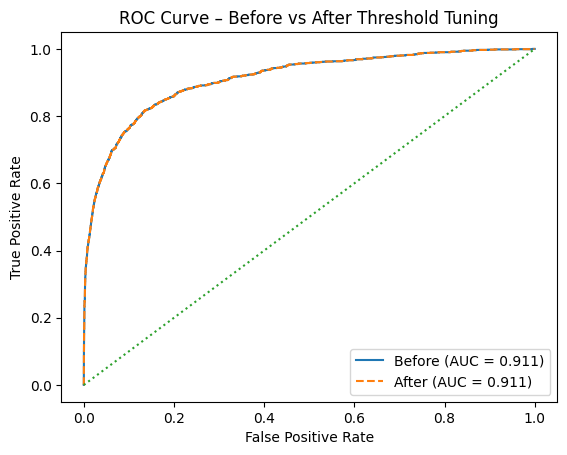

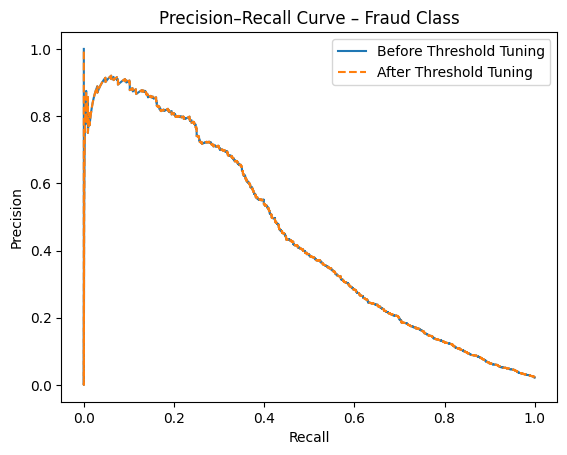

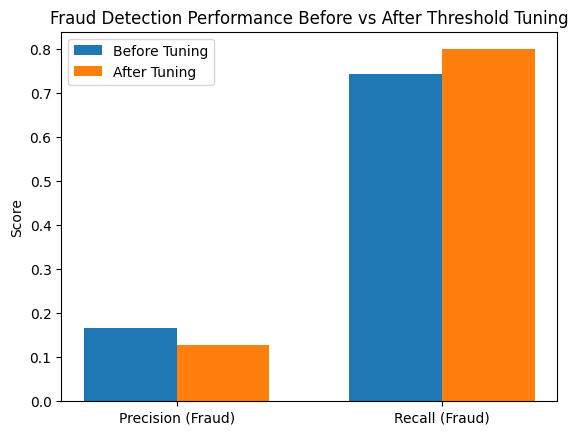

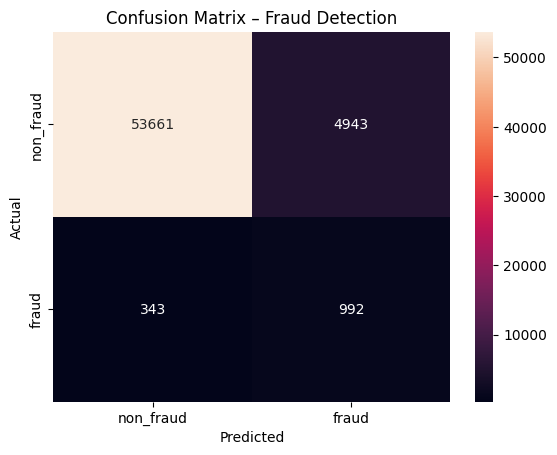

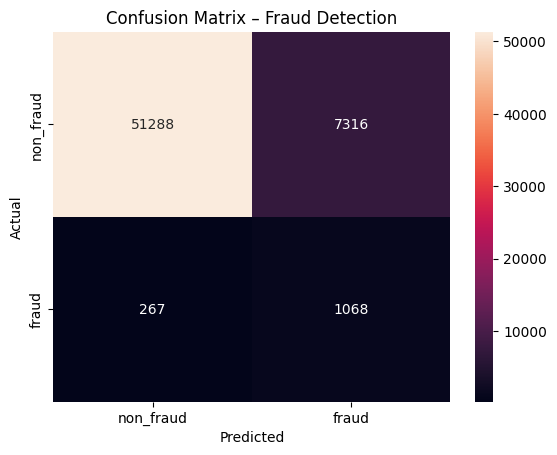

In [17]:
with open("results/autoencoder+MLP_evaluation_results.json", "r") as f:
    before = json.load(f)

with open("results/threshold_tuned_autoencoder+MLP_evaluation_results.json", "r") as f:
    after = json.load(f)

# ROC CURVE Comparision
plt.figure()
plt.plot(
    before["roc_curve"]["fpr"],
    before["roc_curve"]["tpr"],
    label=f"Before (AUC = {before['roc_auc']:.3f})"
)

plt.plot(
    after["roc_curve"]["fpr"],
    after["roc_curve"]["tpr"],
    linestyle="--",
    label=f"After (AUC = {after['roc_auc']:.3f})"
)

plt.plot([0, 1], [0, 1], linestyle=":")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Before vs After Threshold Tuning")
plt.legend()
plt.show()

# Precision_Recall Curve Comparision
plt.figure()
plt.plot(
    before["precision_recall_curve"]["recall"],
    before["precision_recall_curve"]["precision"],
    label="Before Threshold Tuning"
)

plt.plot(
    after["precision_recall_curve"]["recall"],
    after["precision_recall_curve"]["precision"],
    linestyle="--",
    label="After Threshold Tuning"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve – Fraud Class")
plt.legend()
plt.show()


# Fraud Detection
labels = ["Precision (Fraud)", "Recall (Fraud)"]

before_values = [
    before["classification_report"]["1"]["precision"],
    before["classification_report"]["1"]["recall"]
]

after_values = [
    after["classification_report"]["1"]["precision"],
    after["classification_report"]["1"]["recall"]
]

x = np.arange(len(labels))
width = 0.35

plt.figure()
plt.bar(x - width/2, before_values, width, label="Before Tuning")
plt.bar(x + width/2, after_values, width, label="After Tuning")

plt.xticks(x, labels)
plt.ylabel("Score")
plt.title("Fraud Detection Performance Before vs After Threshold Tuning")
plt.legend()
plt.show()

# Confusion Matrix Comparision
cm_before = np.array(before["confusion_matrix"]["matrix"])
cm_after = np.array(after["confusion_matrix"]["matrix"])

labels = before["confusion_matrix"]["labels"]

plt.figure()
sns.heatmap(cm_before, annot=True, fmt='d',
            xticklabels=labels,
            yticklabels=labels)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix – Fraud Detection")
plt.show()

plt.figure()
sns.heatmap(cm_after, annot=True, fmt='d',
            xticklabels=labels,
            yticklabels=labels)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix – Fraud Detection")
plt.show()


